In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [5]:
from nltk.stem import PorterStemmer
import re
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
import tensorflow as tf
from sklearn.model_selection import train_test_split

In [6]:
true_news=pd.read_csv(r'C:\Users\user\Downloads\True.csv')

In [7]:
fake_news=pd.read_csv(r'C:\Users\user\Downloads\Fake.csv')

In [8]:
true_news.head(2)

,title,text,subject,date
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017"
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017"


In [9]:
fake_news.head(2)

,title,text,subject,date
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017"
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017"


In [10]:
true_df=pd.concat([true_news['title'],pd.Series(0,index=true_news.index,name='label')],axis=1)
fake_df=pd.concat([fake_news['title'],pd.Series(1,index=fake_news.index,name='label')],axis=1)

In [11]:
true_df.head()

,title,label
0,"As U.S. budget fight looms, Republicans flip t...",0
1,U.S. military to accept transgender recruits o...,0
2,Senior U.S. Republican senator: 'Let Mr. Muell...,0
3,FBI Russia probe helped by Australian diplomat...,0
4,Trump wants Postal Service to charge 'much mor...,0


In [12]:
fake_df.head()

,title,label
0,Donald Trump Sends Out Embarrassing New Year’...,1
1,Drunk Bragging Trump Staffer Started Russian ...,1
2,Sheriff David Clarke Becomes An Internet Joke...,1
3,Trump Is So Obsessed He Even Has Obama’s Name...,1
4,Pope Francis Just Called Out Donald Trump Dur...,1


In [13]:
news_df=pd.concat([true_df,fake_df],axis=0).sample(frac=1.0,random_state=34).reset_index(drop=True)

In [14]:
news_df.isnull().sum()

title    0
label    0
dtype: int64

In [15]:
news_df

,title,label
0,SUNDAY SCREENING: ‘The War on Democracy’ (2007),1
1,SAY WHAT? Obama Gives Go Ahead For New UN “Reg...,1
2,U.S. farm groups oppose Trump's cuts to agricu...,0
3,BREAKING: Federal Judge STOPS Obamacare Transg...,1
4,OBAMA NOMINATES FIRST MUSLIM FOR FEDERAL BENCH...,1
...,...,...
44893,Laura Bush Stuns Republican Party – Hinted Th...,1
44894,"Here’s How Much Trump Is Paying Omarosa, Kell...",1
44895,REALLY FAKE NEWS: New York Times Finally Retra...,1
44896,WHOA! SENATOR TOM COTTON Blasts Harry Reid’s “...,1


PREPROCESSING

In [16]:
ps=PorterStemmer()
def process_title(title):
    new_title=title.lower()
    new_title=re.sub(r'\$[^\s]+','dollar',new_title)
    new_title=re.sub(r'[^a-z0-9\s]','',new_title)
    new_title=re.sub(r'[0-9]+','number',new_title)
    new_title=new_title.split(' ')
    new_title=list(map(lambda x:ps.stem(x),new_title))
    new_title=list(map(lambda x:x.strip(),new_title))
    if '' in new_title:
        new_title.remove('')
    return new_title

In [17]:
titles=news_df['title'].apply(process_title)
labels=np.array(news_df['label'])

In [18]:
titles

0        [sunday, screen, the, war, on, democraci, number]
1        [say, what, obama, give, go, ahead, for, new, ...
2        [us, farm, group, oppos, trump, cut, to, agric...
3        [break, feder, judg, stop, obamacar, transgend...
4        [obama, nomin, first, muslim, for, feder, benc...
                               ...                        
44893    [laura, bush, stun, republican, parti, , hint,...
44894    [here, how, much, trump, is, pay, omarosa, kel...
44895    [realli, fake, news, new, york, time, final, r...
44896    [whoa, senat, tom, cotton, blast, harri, reid,...
44897    [uk, may, to, visit, china, around, jan, numbe...
Name: title, Length: 44898, dtype: object

In [19]:
#Finding no of unque values in vocabulary and max length

In [20]:
vocab=set()
for title in titles:
    for word in title:
        if word not in vocab:
            vocab.add(word)
vocab_length=len(vocab)


max_seq_length=0
for title in titles:
    if len(title)>max_seq_length:
        max_seq_length=len(title)

print("vocab_length:",vocab_length)
print("max_seq_length:",max_seq_length)

vocab_length: 17807
max_seq_length: 44


Tokenization

In [21]:
tokenizer=Tokenizer(num_words=vocab_length)
tokenizer.fit_on_texts(titles)

In [22]:
sequences=tokenizer.texts_to_sequences(titles)


In [23]:
sequences[0]

[873, 1523, 8, 125, 7, 1459, 13]

In [24]:
word_index=tokenizer.word_index

In [25]:
model_inputs=pad_sequences(sequences,maxlen=max_seq_length,padding='post')

In [26]:
model_inputs

array([[ 873, 1523,    8, ...,    0,    0,    0],
       [  12,   90,   16, ...,    0,    0,    0],
       [   9, 3202,  190, ...,    0,    0,    0],
       ...,
       [ 439,  195,   64, ...,    0,    0,    0],
       [ 795,   38, 1712, ...,    0,    0,    0],
       [ 231,  100,    1, ...,    0,    0,    0]],
      shape=(44898, 44), dtype=int32)

In [27]:
model_inputs.shape

(44898, 44)

In [28]:
 X_train, X_test, y_train, y_test = train_test_split(model_inputs, labels, test_size=0.33, random_state=42)

Training

In [29]:
embedding_dim=64
input=tf.keras.Input(shape=(max_seq_length,))
embedding=tf.keras.layers.Embedding(input_dim=vocab_length,output_dim=embedding_dim,input_length=max_seq_length)(input)
gru=tf.keras.layers.GRU(units=embedding_dim)(embedding)
outputs=tf.keras.layers.Dense(1,activation='sigmoid')(gru)
model=tf.keras.Model(input,outputs)
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

C:\Users\user\anaconda3\Lib\site-packages\keras\src\layers\core\embedding.py:123: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [30]:
batch_size=32
epochs=5

In [31]:
history=model.fit(X_train,y_train,validation_split=0.2,batch_size=batch_size,epochs=epochs)

Epoch 1/5
752/752 ━━━━━━━━━━━━━━━━━━━━ 23s 27ms/step - accuracy: 0.5246 - loss: 0.6923 - val_accuracy: 0.5227 - val_loss: 0.6922
Epoch 2/5
752/752 ━━━━━━━━━━━━━━━━━━━━ 22s 30ms/step - accuracy: 0.5249 - loss: 0.6921 - val_accuracy: 0.5227 - val_loss: 0.6922
Epoch 3/5
752/752 ━━━━━━━━━━━━━━━━━━━━ 22s 30ms/step - accuracy: 0.7643 - loss: 0.3930 - val_accuracy: 0.9503 - val_loss: 0.1398
Epoch 4/5
752/752 ━━━━━━━━━━━━━━━━━━━━ 40s 29ms/step - accuracy: 0.9685 - loss: 0.0867 - val_accuracy: 0.9648 - val_loss: 0.1029
Epoch 5/5
752/752 ━━━━━━━━━━━━━━━━━━━━ 39s 26ms/step - accuracy: 0.9858 - loss: 0.0399 - val_accuracy: 0.9663 - val_loss: 0.1138


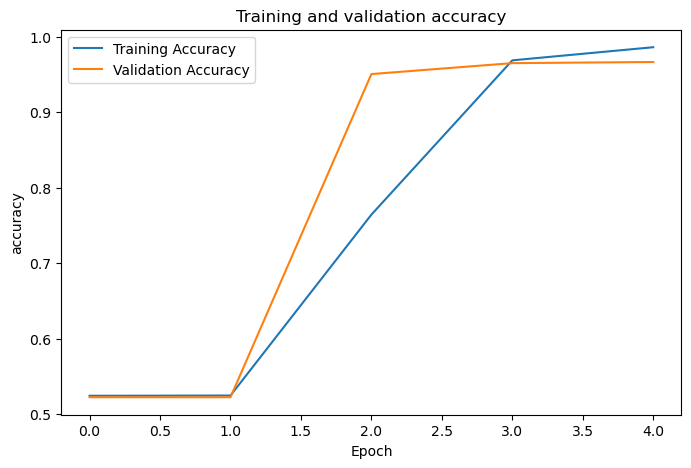

In [32]:
plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'],label='Training Accuracy')
plt.plot(history.history['val_accuracy'],label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('accuracy')
plt.title('Training and validation accuracy')
plt.legend()
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

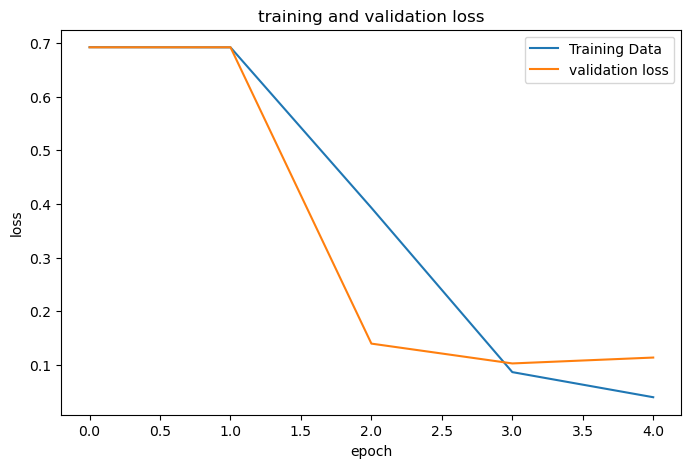

In [33]:
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'],label='Training Data')
plt.plot(history.history['val_loss'],label='validation loss')
plt.title('training and validation loss')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.show
    

Evaluation

In [34]:
accuarcy=model.evaluate(X_test,y_test)


464/464 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9629 - loss: 0.1153


In [35]:
y_pred=model.predict(X_test)

464/464 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step


In [36]:
from sklearn.metrics import classification_report,confusion_matrix

In [37]:
y_pred_classes=(y_pred>0.5).astype(int).flatten()

In [38]:
print(classification_report(y_test,y_pred_classes))

              precision    recall  f1-score   support

           0       0.96      0.97      0.96      7113
           1       0.97      0.96      0.96      7704

    accuracy                           0.96     14817
   macro avg       0.96      0.96      0.96     14817
weighted avg       0.96      0.96      0.96     14817



In [39]:
cm=confusion_matrix(y_test,y_pred_classes)

In [40]:
cm

array([[6878,  235],
       [ 314, 7390]])

In [41]:
import os 
import pickle

In [42]:
model_dir='Artifact'
os.makedirs(model_dir,exist_ok=True)

In [43]:
model.save(os.path.join(model_dir,'model.keras'))